In [1]:
# importing the neccessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error as RMSE, mean_absolute_error as MAE

In [2]:
# Load Data
railway_df = pd.read_csv("CleanedRailway.csv", parse_dates=['Date of Journey', 'Date of Purchase'])
display(railway_df.head())
display(railway_df.info())

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,...,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Delay Duration,Journey ID,Route Code
0,da8a6ba8-b3dc-4677-b176,2023-12-08,2023-12-08 12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,2024-01-01,2024-01-01 11:00:00,2024-01-01 13:30:00,2024-01-01 13:30:00,On Time,NaN,No,0 days 00:00:00,PAD-LIV:20240101:1100,PAD-LIV
1,b0cdd1b0-f214-4197-be53,2023-12-16,2023-12-16 11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,2024-01-01,2024-01-01 09:45:00,2024-01-01 11:35:00,2024-01-01 11:40:00,Delayed,Signal Failure,No,0 days 00:05:00,KGX-YRK:20240101:0945,KGX-YRK
2,f3ba7a96-f713-40d9-9629,2023-12-19,2023-12-19 19:51:27,Online,Credit Card,No Railcard,Standard,Advance,3,Liverpool Lime Street,...,2024-01-02,2024-01-02 18:15:00,2024-01-02 18:45:00,2024-01-02 18:45:00,On Time,NaN,No,0 days 00:00:00,LIV-MAN:20240102:1815,LIV-MAN
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,2023-12-20 23:00:36,Station,Credit Card,No Railcard,Standard,Advance,13,London Paddington,...,2024-01-01,2024-01-01 21:30:00,2024-01-01 22:30:00,2024-01-01 22:30:00,On Time,NaN,No,0 days 00:00:00,PAD-RDG:20240101:2130,PAD-RDG
4,2be00b45-0762-485e-a7a3,2023-12-27,2023-12-27 18:22:56,Online,Contactless,No Railcard,Standard,Advance,76,Liverpool Lime Street,...,2024-01-01,2024-01-01 16:45:00,2024-01-01 19:00:00,2024-01-01 19:00:00,On Time,NaN,No,0 days 00:00:00,LIV-EUS:20240101:1645,LIV-EUS


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction ID       31653 non-null  object        
 1   Date of Purchase     31653 non-null  datetime64[ns]
 2   Time of Purchase     31653 non-null  object        
 3   Purchase Type        31653 non-null  object        
 4   Payment Method       31653 non-null  object        
 5   Railcard             31653 non-null  object        
 6   Ticket Class         31653 non-null  object        
 7   Ticket Type          31653 non-null  object        
 8   Price                31653 non-null  int64         
 9   Departure Station    31653 non-null  object        
 10  Arrival Destination  31653 non-null  object        
 11  Date of Journey      31653 non-null  datetime64[ns]
 12  Departure Time       31653 non-null  object        
 13  Arrival Time         31653 non-

None

In [3]:
# Load the calendar table
calendar = pd.read_csv('Calendar.csv', parse_dates=['Date'])
display(calendar)
calendar.info()

,Date,Year,Quarter,Month,Month Name,Week,Day of Week,Day Type,Holiday Name
0,2023-12-01,2023,4,12,Dec,48,Fri,Workday,NaN
1,2023-12-02,2023,4,12,Dec,48,Sat,Weekend,NaN
2,2023-12-03,2023,4,12,Dec,48,Sun,Weekend,NaN
3,2023-12-04,2023,4,12,Dec,49,Mon,Workday,NaN
4,2023-12-05,2023,4,12,Dec,49,Tue,Workday,NaN
...,...,...,...,...,...,...,...,...,...
178,2024-05-27,2024,2,5,May,22,Mon,Holiday,Spring bank holiday
179,2024-05-28,2024,2,5,May,22,Tue,Workday,NaN
180,2024-05-29,2024,2,5,May,22,Wed,Workday,NaN
181,2024-05-30,2024,2,5,May,22,Thu,Workday,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          183 non-null    datetime64[ns]
 1   Year          183 non-null    int64         
 2   Quarter       183 non-null    int64         
 3   Month         183 non-null    int64         
 4   Month Name    183 non-null    object        
 5   Week          183 non-null    int64         
 6   Day of Week   183 non-null    object        
 7   Day Type      183 non-null    object        
 8   Holiday Name  7 non-null      object        
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 13.0+ KB


### Aggregate daily data


In [4]:
# Aggregate daily data
daily_data = railway_df.groupby('Date of Journey').agg(
    # Booking metrics
    Bookings=('Transaction ID', 'count'),  # Count all tickets sold
    Journeys= ('Journey ID', 'nunique'),   # Count distinct Journeys

    # Journey status metrics
    Delayed_Journeys= ('Journey ID', lambda x: (x[railway_df['Journey Status'] == 'Delayed'].nunique())),
    Cancelled_Journeys= ('Journey ID', lambda x: (x[railway_df['Journey Status'] == 'Cancelled'].nunique())),
                         
    # Financial metrics
    Revenue=('Price', 'sum'),
    Refunded=('Price', lambda x: x[railway_df['Refund Request'] == 'Yes'].sum()),

    # First Class demand
    First_Class=('Ticket Class', lambda x: (x == 'First Class').sum()),
).reset_index()

# Display the processed dataframe
daily_data

,Date of Journey,Bookings,Journeys,Delayed_Journeys,Cancelled_Journeys,Revenue,Refunded,First_Class
0,2024-01-01,66,61,5,0,1682,41,4
1,2024-01-02,146,112,6,8,4830,102,19
2,2024-01-03,292,168,10,8,7159,437,31
3,2024-01-04,274,176,7,9,7063,560,25
4,2024-01-05,253,159,8,3,5934,202,22
...,...,...,...,...,...,...,...,...
116,2024-04-26,270,173,11,6,6125,274,31
117,2024-04-27,269,161,12,8,6707,598,25
118,2024-04-28,292,190,8,9,6655,250,36
119,2024-04-29,249,160,8,6,5893,430,27


In [5]:
# Merge calendar data with transaction data
daily_data = pd.merge(
    # Calendar features (date-related attributes)
    calendar[['Date', 'Month', 'Week', 'Day of Week', 'Day Type']],
    daily_data,
    how="inner",  # Keep only matching records
    left_on='Date',  # Join key from calendar
    right_on='Date of Journey'  # Join key from transactions
)

# Remove duplicate date column (keep 'Date' from calendar)
daily_data = daily_data.drop(columns=['Date of Journey'])

# Convert day of week to numerical index (Monday=0 to Sunday=6)
daily_data['Day of Week'] = daily_data['Date'].dt.dayofweek

# Display the processed dataframe
daily_data

,Date,Month,Week,Day of Week,Day Type,Bookings,Journeys,Delayed_Journeys,Cancelled_Journeys,Revenue,Refunded,First_Class
0,2024-01-01,1,1,0,Holiday,66,61,5,0,1682,41,4
1,2024-01-02,1,1,1,Workday,146,112,6,8,4830,102,19
2,2024-01-03,1,1,2,Workday,292,168,10,8,7159,437,31
3,2024-01-04,1,1,3,Workday,274,176,7,9,7063,560,25
4,2024-01-05,1,1,4,Workday,253,159,8,3,5934,202,22
...,...,...,...,...,...,...,...,...,...,...,...,...
116,2024-04-26,4,17,4,Workday,270,173,11,6,6125,274,31
117,2024-04-27,4,17,5,Weekend,269,161,12,8,6707,598,25
118,2024-04-28,4,17,6,Weekend,292,190,8,9,6655,250,36
119,2024-04-29,4,18,0,Workday,249,160,8,6,5893,430,27


In [6]:
daily_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                121 non-null    datetime64[ns]
 1   Month               121 non-null    int64         
 2   Week                121 non-null    int64         
 3   Day of Week         121 non-null    int32         
 4   Day Type            121 non-null    object        
 5   Bookings            121 non-null    int64         
 6   Journeys            121 non-null    int64         
 7   Delayed_Journeys    121 non-null    int64         
 8   Cancelled_Journeys  121 non-null    int64         
 9   Revenue             121 non-null    int64         
 10  Refunded            121 non-null    int64         
 11  First_Class         121 non-null    int64         
dtypes: datetime64[ns](1), int32(1), int64(9), object(1)
memory usage: 11.0+ KB


In [7]:
# Display Daily date column names:
print('Columns in the dataset:')
display(daily_data.columns.tolist())

Columns in the dataset:


['Date',
 'Month',
 'Week',
 'Day of Week',
 'Day Type',
 'Bookings',
 'Journeys',
 'Delayed_Journeys',
 'Cancelled_Journeys',
 'Revenue',
 'Refunded',
 'First_Class']

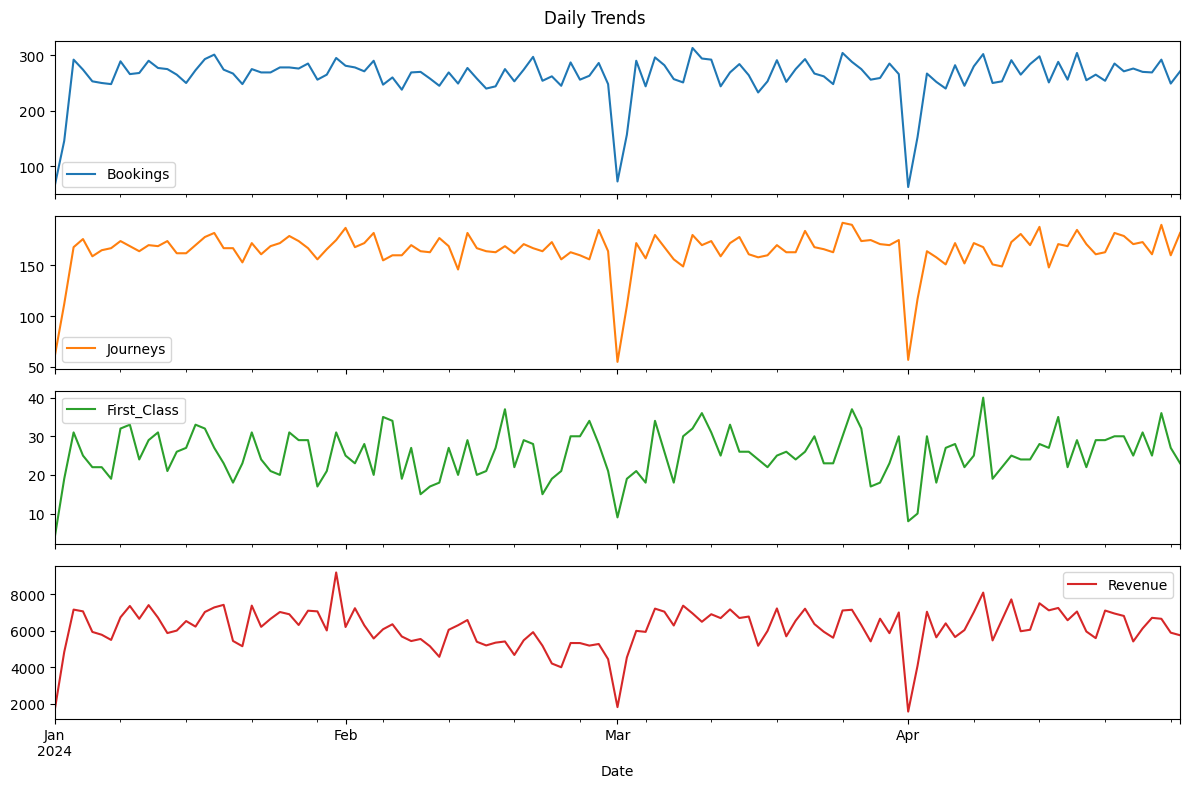

In [8]:
# ----------------------------------------
# 1. Daily Data Analysis
# ----------------------------------------
# Plot daily trends for all targets
targets = ['Bookings', 'Journeys','First_Class', 'Revenue']
daily_data.set_index('Date')[targets].plot(subplots=True, figsize=(12, 8), title='Daily Trends')
plt.tight_layout()
plt.show()

Do holidays show spikes/drops in cancellations or revenue?

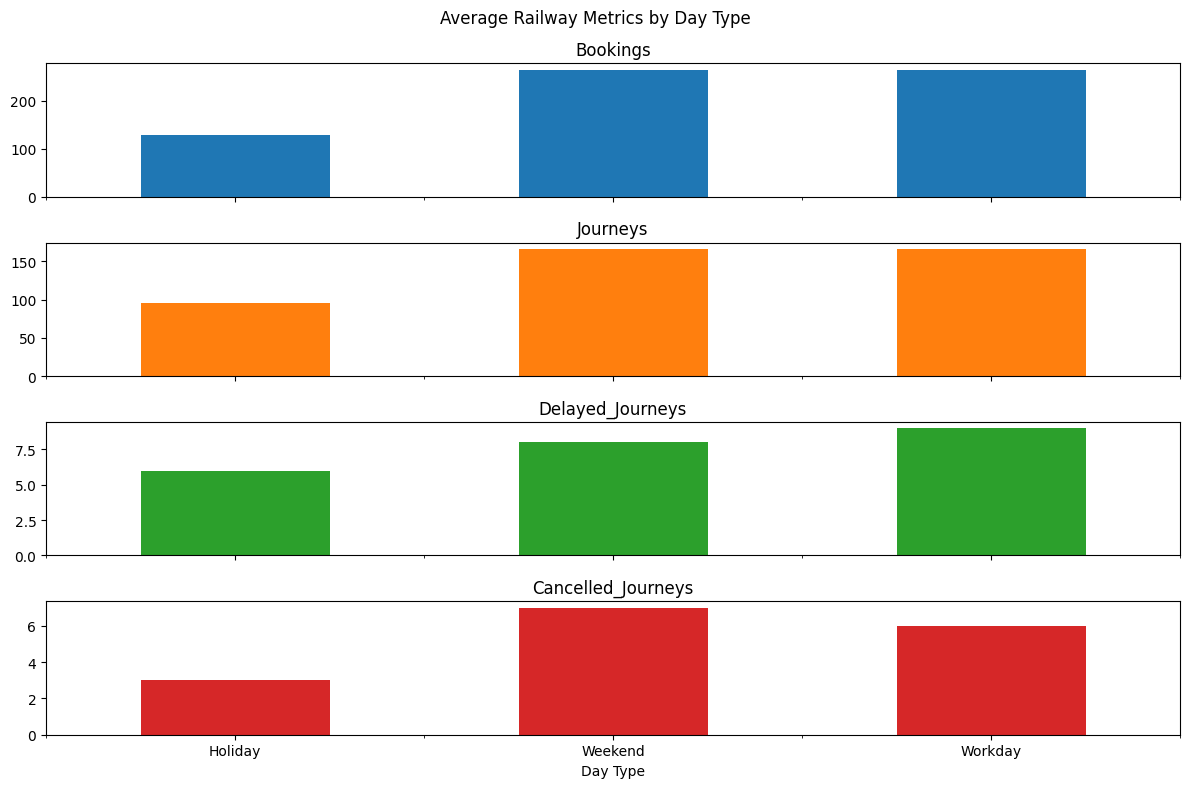

,Bookings,Journeys,Delayed_Journeys,Cancelled_Journeys
Day Type,,,,
Holiday,129,96,6,3
Weekend,264,166,8,7
Workday,265,166,9,6


In [9]:
# Calculate average metrics by day type
daily_metrics_by_day_type = daily_data.groupby('Day Type')[
    ['Bookings', 'Journeys', 'Delayed_Journeys', 'Cancelled_Journeys']
].mean().round().astype('int')

# Create bar plot with descriptive title
daily_metrics_by_day_type.plot.bar(
    subplots=True,
    figsize=(12, 8),
    title='Average Railway Metrics by Day Type',
    rot=0,  # Rotate x-axis labels for better readability
    legend=False  # Since we're using subplots, legends are redundant
)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Return the calculated metrics
daily_metrics_by_day_type

Is there a monthly trend (e.g., increasing bookings over time)?

,Bookings,Journeys,Revenue
Month,,,
1,8111,5060,199618
2,7644,4839,159374
3,8117,5083,195147
4,7781,4889,187782


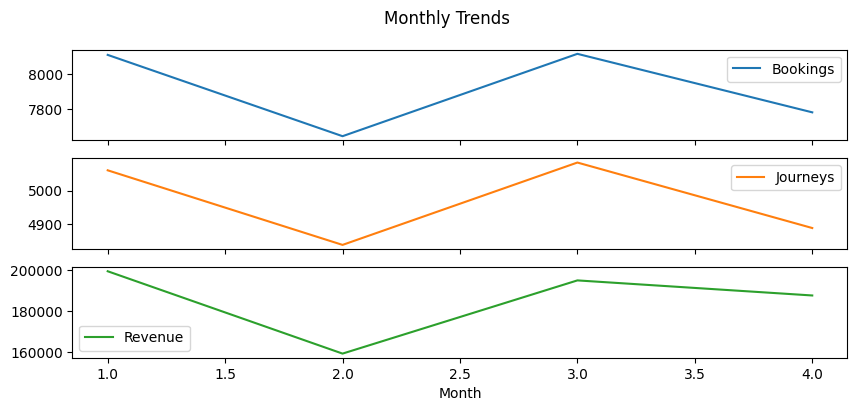

In [10]:
# ----------------------------------------
# 2. Monthly Data Analysis
# ----------------------------------------
# Aggregate to monthly trends (if needed)
monthly_trends = daily_data.groupby('Month')[['Bookings', 'Journeys', 'Revenue']].sum()
monthly_trends.plot(subplots=True, figsize=(10, 4), title='Monthly Trends')
# plt.show()
monthly_trends

#### 2. Feature Engineering & Encoding

In [11]:
# Cyclical encoding
def encode_cyclical(df, col, max_val):
    df[col+'_sin'] = np.sin(2 * np.pi * df[col]/max_val)
    df[col+'_cos'] = np.cos(2 * np.pi * df[col]/max_val)
    return df
    
df = daily_data

# df = encode_cyclical(df, 'Day of Week', 7)

# Binary flags
df['Is_Weekend'] = (df['Day Type'] == 'Weekend').astype(int)
df['Is_Holiday'] = (df['Day Type'] == 'Holiday').astype(int)

# Drop original temporal columns
# df = df.drop(columns=['Day of Week', 'Day Type'])
df = df.drop(columns=[ 'Day Type'])

# Display the new dataframe
display(df)

,Date,Month,Week,Day of Week,Bookings,Journeys,Delayed_Journeys,Cancelled_Journeys,Revenue,Refunded,First_Class,Is_Weekend,Is_Holiday
0,2024-01-01,1,1,0,66,61,5,0,1682,41,4,0,1
1,2024-01-02,1,1,1,146,112,6,8,4830,102,19,0,0
2,2024-01-03,1,1,2,292,168,10,8,7159,437,31,0,0
3,2024-01-04,1,1,3,274,176,7,9,7063,560,25,0,0
4,2024-01-05,1,1,4,253,159,8,3,5934,202,22,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,2024-04-26,4,17,4,270,173,11,6,6125,274,31,0,0
117,2024-04-27,4,17,5,269,161,12,8,6707,598,25,1,0
118,2024-04-28,4,17,6,292,190,8,9,6655,250,36,1,0
119,2024-04-29,4,18,0,249,160,8,6,5893,430,27,0,0


In [12]:
# Display the timeseries dataframe
display(df)

,Date,Month,Week,Day of Week,Bookings,Journeys,Delayed_Journeys,Cancelled_Journeys,Revenue,Refunded,First_Class,Is_Weekend,Is_Holiday
0,2024-01-01,1,1,0,66,61,5,0,1682,41,4,0,1
1,2024-01-02,1,1,1,146,112,6,8,4830,102,19,0,0
2,2024-01-03,1,1,2,292,168,10,8,7159,437,31,0,0
3,2024-01-04,1,1,3,274,176,7,9,7063,560,25,0,0
4,2024-01-05,1,1,4,253,159,8,3,5934,202,22,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,2024-04-26,4,17,4,270,173,11,6,6125,274,31,0,0
117,2024-04-27,4,17,5,269,161,12,8,6707,598,25,1,0
118,2024-04-28,4,17,6,292,190,8,9,6655,250,36,1,0
119,2024-04-29,4,18,0,249,160,8,6,5893,430,27,0,0


In [13]:
# df.to_csv('Daily Data.csv', index=False)

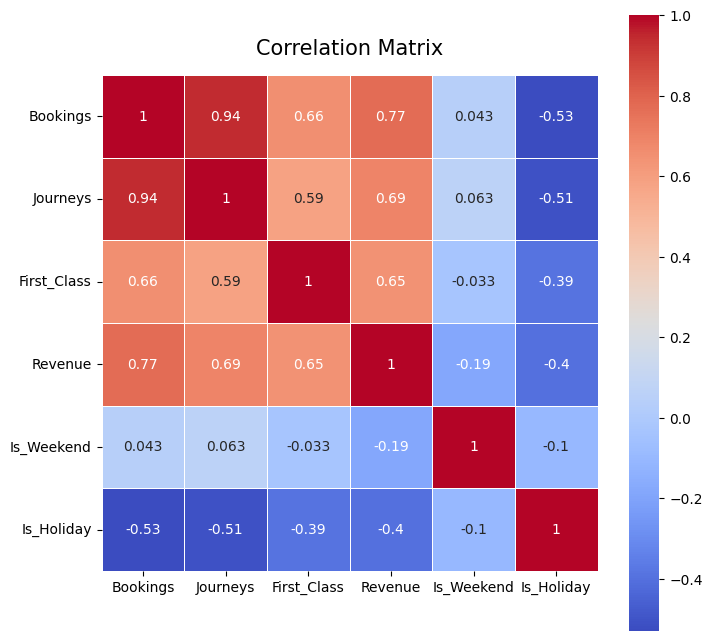

In [14]:
# Compute the correlation matrix
corr =  df[['Bookings',
            'Journeys',
            'First_Class',
            'Revenue',
            'Is_Weekend',
            'Is_Holiday']].corr()

# Plot the correlation matrix using Seaborn
plt.figure(figsize=(8, 8))
sns.heatmap(
    corr,
    annot=True,        # Display correlation values
    cmap="coolwarm",  # Use the coolwarm colormap
    #vmin=-1,          # Minimum value for colormap (correlation ranges from -1 to 1)
    #vmax=1,           # Maximum value for colormap
    linewidths=0.5,   # Add lines between cells
    square=True       # Ensure cells are square-shaped
)

# Add a title
plt.title("Correlation Matrix", pad=15, fontsize=15)
plt.yticks(rotation=0)

# Display the plot
plt.show()

## Biulding the model using Prophet

In [15]:
# Install Prophet package
# !pip install prophet

In [16]:
from prophet import Prophet

# Prepare the DataFrame for Prophet: ds and y. Also include extra regressors: Is_Holiday and Is_Weekend.
prophet_df = df[['Date', 'Bookings', 'Is_Holiday', 'Is_Weekend']].rename(columns={'Date':'ds', 'Bookings':'y'})

# Initialize the Prophet model
model = Prophet(daily_seasonality=True, weekly_seasonality=True, seasonality_mode='multiplicative')

# Add extra regressors
model.add_regressor('Is_Holiday')
model.add_regressor('Is_Weekend')

# Fit the mod
model.fit(prophet_df)

print('Prophet model fitted on Bookings with regressors Is_Holiday and Is_Weekend.')

03:57:36 - cmdstanpy - INFO - Chain [1] start processing
03:57:37 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted on Bookings with regressors Is_Holiday and Is_Weekend.


In [17]:
# Create a dataframe to hold predictions for the next 31 days
may = calendar[
    (calendar['Date'] >= '2024-05-01') & (calendar['Date'] <= '2024-05-31')
    ][['Date', 'Day Type']].reset_index(drop=True)

# Rename the "Date" to 'ds'
may_ds = may.rename(columns={'Date': 'ds'})

# Binary flags
may_ds['Is_Weekend'] = (may_ds['Day Type'] == 'Weekend').astype(int)
may_ds['Is_Holiday'] = (may_ds['Day Type'] == 'Holiday').astype(int)

# Drop the original 'Day Type' column
may_ds = may_ds.drop(columns=['Day Type'])

# Display the new dataframe
display(may_ds)

,ds,Is_Weekend,Is_Holiday
0,2024-05-01,0,0
1,2024-05-02,0,0
2,2024-05-03,0,0
3,2024-05-04,1,0
4,2024-05-05,1,0
5,2024-05-06,0,1
6,2024-05-07,0,0
7,2024-05-08,0,0
8,2024-05-09,0,0
9,2024-05-10,0,0


In [18]:
# Forecast using the model
forecast = model.predict(may_ds)

In [19]:
# Display forecast output
forecasted = pd.merge(
    may,
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    how='left',
    left_on='Date',
    right_on='ds'
).drop(columns='ds')

# Round to 1 decimal place
forecasted[['yhat', 'yhat_lower', 'yhat_upper']] = forecasted[['yhat', 'yhat_lower', 'yhat_upper']].round(0).astype(int)

# print("Forecasted:")
# display(forecasted)

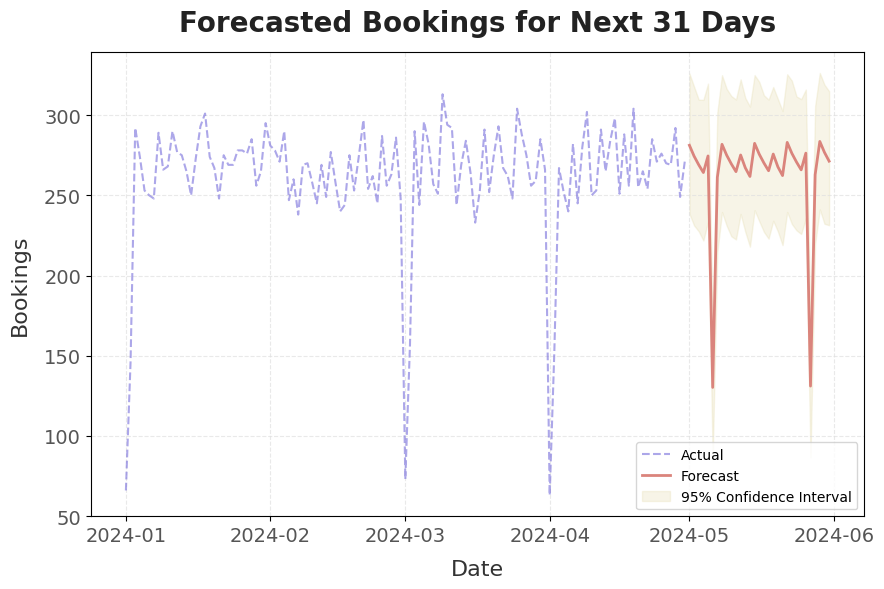

In [20]:
# Set up the plot with scientific theme
plt.figure(figsize=(9, 6))
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)

# Plot actual data
plt.plot(prophet_df['ds'], prophet_df['y'], '--', color='#766CDB', alpha=0.6, label='Actual')

# Plot forecast
plt.plot(forecast['ds'], forecast['yhat'], '-', color='#DA847C', linewidth=2, label='Forecast')

# Plot confidence intervals
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                 color='#D9CC8B', alpha=0.2, label='95% Confidence Interval')

# Formatting
plt.title('Forecasted Bookings for Next 31 Days', pad=15, fontsize=20, fontweight='semibold', color='#222222')
plt.xlabel('Date', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.ylabel('Bookings', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.grid(True, linestyle='--', alpha=0.7, color='#E0E0E0')
plt.legend(loc='lower right', fontsize=10)
plt.xticks(fontsize=14, color='#555555')
plt.yticks(fontsize=14, color='#555555')

# Show the plot
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error as MAE,\
                            mean_absolute_percentage_error as MAPE,\
                            root_mean_squared_error as RMSE,\
                            r2_score

# Calculate model performance metrics on the training data
y_true = prophet_df['y'].values
y_pred = model.predict(prophet_df)['yhat'].values

# Compute metrics
rmse = RMSE(y_true, y_pred)
mae = MAE(y_true, y_pred)
mape = MAPE(y_true, y_pred) * 100  # convert to percentage

# Display results
print("Model Performance Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

Model Performance Metrics:
RMSE: 33.15
MAE: 20.90
MAPE: 11.25%


Based on the model performance metrics:

* RMSE (Root Mean Square Error): 33.15 - This indicates that, on average, our predictions deviate from actual values by about 33 bookings. Given that the average number of bookings appears to be around 260-290 per day, this represents roughly a 10-15% error margin.

* MAE (Mean Absolute Error): 20.9 - On average, our predictions are off by about 21 bookings in either direction.

* MAPE (Mean Absolute Percentage Error): 11.25% - This is perhaps the most intuitive metric, showing that our predictions are typically within 11.25% of the actual values, which is reasonably good for time series forecasting.

The forecast shows a relatively stable pattern with appropriate confidence intervals for the next 31 days. The model has incorporated both weekend effects and holiday impacts.

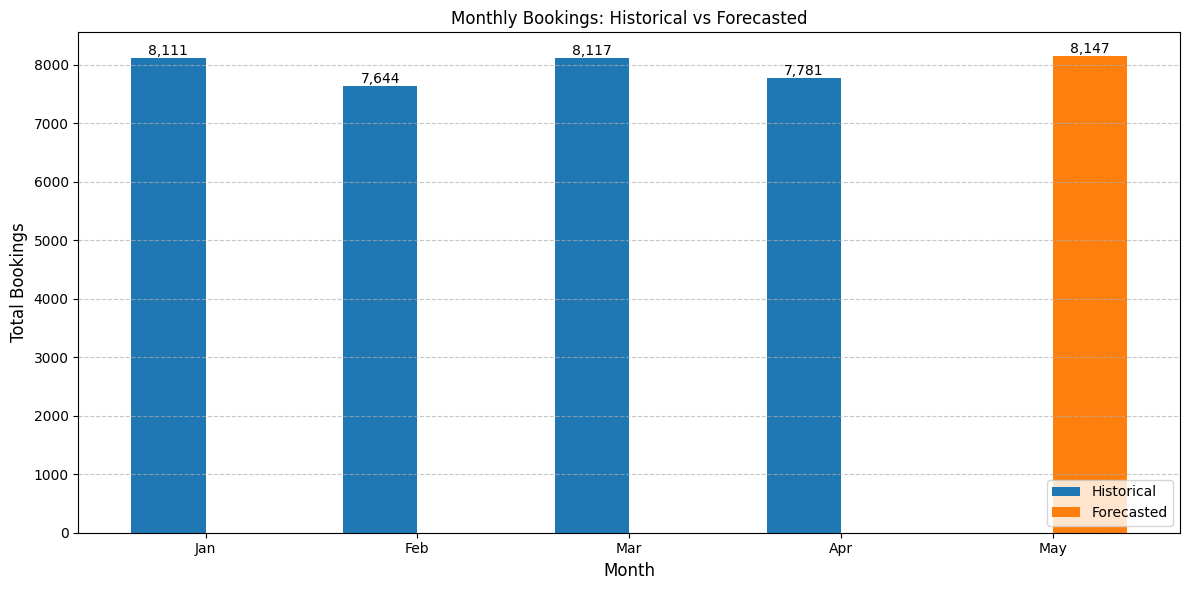

In [22]:
# Aggregate historical data to monthly
historical_monthly = (
    daily_data.groupby('Month')[['Bookings']]
    .sum()
    .rename(columns={'Bookings': 'Historical Bookings'})
)

# Ensure 'Date' is datetime and extract month
forecasted['Date'] = pd.to_datetime(forecasted['Date'])
forecasted['Month'] = forecasted['Date'].dt.month

# Aggregate forecasted data to monthly
forecasted_monthly = (
    forecasted.groupby('Month')[['yhat']]
    .sum()
    .rename(columns={'yhat': 'Forecasted Bookings'})
)

# Combine historical and forecasted data
combined = pd.concat([historical_monthly, forecasted_monthly], axis=1)

# Filter out rows where BOTH are zero (keep if either is non-zero)
combined = combined[(combined['Historical Bookings'] != 0) | (combined['Forecasted Bookings'] != 0)]

# Map month numbers to names (e.g., 1 → "Jan")
combined.index = combined.index.map(lambda x: pd.to_datetime(str(x), format='%m').strftime('%b'))

# Plot
ax = combined.plot(
    kind='bar',
    figsize=(12, 6),
    title='Monthly Bookings: Historical vs Forecasted',
    color=['#1f77b4', '#ff7f0e'],  # Blue for historical, orange for forecasted
    width=0.7,
    rot=0
)

# Add annotations only for non-zero bars
for p in ax.patches:
    height = p.get_height()
    if height != 0:  # Only annotate non-zero bars
        ax.annotate(
            f"{int(height):,}",
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 5),
            textcoords='offset points',
            fontsize=10
        )

# Customize plot
plt.ylabel('Total Bookings', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(['Historical', 'Forecasted'], loc='lower right')
plt.tight_layout()
plt.show()

In [23]:
# Create a dataframe to hold predictions for the next 31 days
may = calendar[
    (calendar['Date'] >= '2024-05-01') & (calendar['Date'] <= '2024-05-31')
    ][['Date', 'Day Type']].reset_index(drop=True)

# Rename the "Date" to 'ds'
may_ds = may.rename(columns={'Date': 'ds'})

# Binary flags
may_ds['Is_Weekend'] = (may_ds['Day Type'] == 'Weekend').astype(int)
may_ds['Is_Holiday'] = (may_ds['Day Type'] == 'Holiday').astype(int)

# Drop the original 'Day Type' column
may_ds = may_ds.drop(columns=['Day Type'])

# Display the new dataframe
# display(may_ds)

In [24]:
# Forecast using the model
forecast = model.predict(may_ds)

In [26]:
# Display forecast output
forecasted_may = pd.merge(
    may,
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    how='left',
    left_on='Date',
    right_on='ds'
).drop(columns='ds')

# Round to int
forecasted_may[['yhat', 'yhat_lower', 'yhat_upper']] = forecasted_may[['yhat', 'yhat_lower', 'yhat_upper']].round(0).astype(int)
forecasted_may = forecasted_may.rename(columns={'yhat': 'Bookings', 'yhat_lower': 'Booknigs_lower', 'yhat_upper': 'Booking_upper'})

print("Forecasted:")
display(forecasted_may)

Forecasted:


,Date,Day Type,Bookings,Booknigs_lower,Booking_upper
0,2024-05-01,Workday,281,238,326
1,2024-05-02,Workday,274,233,317
2,2024-05-03,Workday,269,227,310
3,2024-05-04,Weekend,264,226,305
4,2024-05-05,Weekend,275,232,319
5,2024-05-06,Holiday,130,91,174
6,2024-05-07,Workday,261,217,303
7,2024-05-08,Workday,282,239,325
8,2024-05-09,Workday,275,236,316
9,2024-05-10,Workday,270,226,314


In [27]:
print(f"\nPrediced Total Bookings for May 2024 = {forecasted_may['Bookings'].sum()} Bookings")


Prediced Total Bookings for May 2024 = 8147 Bookings


In [28]:
# Save the Forecasted values into csv file
forecasted_may.to_csv('Forecasted May.csv', index=False)

***